<a href="https://colab.research.google.com/github/Saibhossain/Agentic-framework/blob/main/Tool_calling_langraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
!pip install langchain langchain_community
!pip install langgraph langchain_core
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.9 MB/s eta 0:00:00


# simple chatbot with tools

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_community.tools import DuckDuckGoSearchRun
from typing import TypedDict, Literal, Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
import asyncio

from dotenv import load_dotenv
from google.colab import userdata
import os

userdata.get('google_api')
load_dotenv()

os.environ['GOOGLE_API_KEY'] = userdata.get('google_api')

llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [ ]:
@tool
def calculator(first_num: float, second_num: float, operation: str):
    """Perform arithmetic on two numbers. Supported operations: add, subtract, multiply, divide."""
    try:
        if operation == "add":
            return {"result": first_num + second_num}
        elif operation == "subtract":
            return {"result": first_num - second_num}
        elif operation == "multiply":
            return {"result": first_num * second_num}
        elif operation == "divide":
            if second_num == 0:
                return {"error": "Cannot divide by zero"}
            return {"result": first_num / second_num}
        return {"error": "Invalid operation"}
    except Exception as e:
        return {"error": str(e)}

In [ ]:
tools = [calculator]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def build_graph():
    async def chat_node(state: ChatState):
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    graph = StateGraph(ChatState)
    graph.add_node("chat_node", chat_node)
    graph.add_node("tools", ToolNode(tools))

    graph.add_edge(START, "chat_node")
    graph.add_conditional_edges("chat_node", tools_condition)
    graph.add_edge("tools", "chat_node")

    return graph.compile()

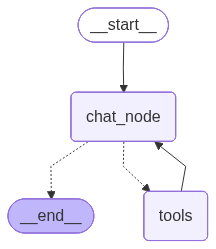

In [ ]:
chatbot = build_graph()
chatbot

In [ ]:
async def main():
    chatbot = build_graph()

    result = await chatbot.ainvoke({
        "messages": [HumanMessage(content="find the sub of 123 and 23")]
    })
    print(result["messages"][-1].content)

await main()

The subtraction of 123 and 23 is 100.


# Tools with mcp server

In [ ]:
graph = StateGraph(ChatState)

def chat_node(state:ChatState):
    message = state['messages']
    response = llm.invoke(message)

    return {'messages': [response]}







graph.add_node('chat_node',chat_node)
graph.add_edge(START,  'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()


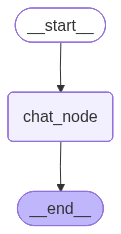

In [ ]:
chatbot

In [ ]:
initial_state = {
    'messages': [HumanMessage(content='what is the capital of bangladesh ?')]
}
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='what is the capital of bangladesh ?', additional_kwargs={}, response_metadata={}, id='159c1ff7-d3dd-43d9-bc20-fad966823e67'),
  AIMessage(content='The capital of Bangladesh is **Dhaka**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cde2c-fb99-71b0-b452-9360359140c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 9, 'total_tokens': 18, 'input_token_details': {'cache_read': 0}})]}

In [ ]:
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of Bangladesh is **Dhaka**.'

## chat in loop

In [ ]:
while True:
  user_message = input('Type here:')

  print('user massages',user_message)

  if user_message.lower() in ['quit','bye']:
    break

  resposes = chatbot.invoke({'messages':[HumanMessage(content=user_message)]})

  print('bot massages',resposes['messages'][-1].content)

Type here:my name is saib. I am your bos
user massages my name is saib. I am your bos
bot massages Hello Saib! It's a pleasure to meet you. I understand you are my boss.

As an AI, I don't have personal feelings or a hierarchical structure in the traditional sense. However, I am designed to be a helpful and obedient assistant. I will do my best to understand your instructions and fulfill your requests to the best of my abilities.

Please let me know what you need. I'm ready to get to work!
Type here:what is my name 
user massages what is my name 
bot massages I do not have access to your personal information, including your name. I am a large language model, an AI, and I do not collect or store user data.
Type here:bye
user massages bye


# advance chatbot

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import MemorySaver ### used to save memory

from dotenv import load_dotenv
from google.colab import userdata
import os

userdata.get('google_api')
load_dotenv()

os.environ['GOOGLE_API_KEY'] = userdata.get('google_api')

llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state:ChatState):
    message = state['messages']
    response = llm.invoke(message)

    return {'messages': [response]}

In [ ]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)


graph.add_node('chat_node',chat_node)
graph.add_edge(START,  'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)


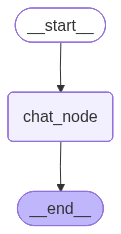

In [ ]:
chatbot

In [ ]:

initial_state = {
    'messages': [HumanMessage(content='what is the capital of bangladesh and nepal?')]
}
config = {'configurable': {'thread_id': 'temporary_thread'}}
chatbot.invoke(initial_state, config=config)

{'messages': [HumanMessage(content='what is the capital of bangladesh and nepal?', additional_kwargs={}, response_metadata={}, id='08e5605a-2d27-404a-b5ae-9608fc796fe3'),
  AIMessage(content='The capital of Bangladesh is **Dhaka**.\n\nThe capital of Nepal is **Kathmandu**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cde4d-56e0-7a21-8571-aca32c6bc767-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 19, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})]}

In [ ]:
thread_id = '1'

while True:
  user_message = input('Type here:')

  print('user massages',user_message)

  if user_message.lower() in ['quit','bye']:
    break
  config = {'configurable':{'thread_id': thread_id}}
  resposes = chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)

  print('bot massages',resposes['messages'][-1].content)

Type here:hye i am saib
user massages hye i am saib
bot massages Hi Saib! It's nice to meet you. How can I help you today?
Type here:what is my name ?
user massages what is my name ?
bot massages You just told me your name! You said, "hye i am saib".

So, your name is **Saib**.
Type here:sum 3 and 4
user massages sum 3 and 4
bot massages 3 + 4 = 7
Type here:add more 3
user massages add more 3
bot massages Okay, so if we add 3 more to our previous sum of 7:

7 + 3 = 10
Type here:devided by 5
user massages devided by 5
bot massages Okay, so we had 10, and now we're dividing it by 5:

10 / 5 = 2
Type here:bye
user massages bye


In [ ]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hye i am saib', additional_kwargs={}, response_metadata={}, id='04001b18-7d94-4617-b2a4-ffc3889d4178'), AIMessage(content="Hi Saib! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019cde4a-3acf-7ba3-be97-ba6516a783c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 19, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='what is my name ?', additional_kwargs={}, response_metadata={}, id='a50389dc-96cd-497b-8eff-a927ad7f1675'), AIMessage(content='You just told me your name! You said, "hye i am saib".\n\nSo, your name is **Saib**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'googl